# Data Visualizations

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [7]:
# Load the dataset and sort the values by Date
df = pd.read_csv("../data/faang_stock_prices.csv")
df["Date"] = pd.to_datetime(df["Date"])
df = df.sort_values("Date")

## Line Chart Comparison of Closing Stock Prices between FAANG Companies

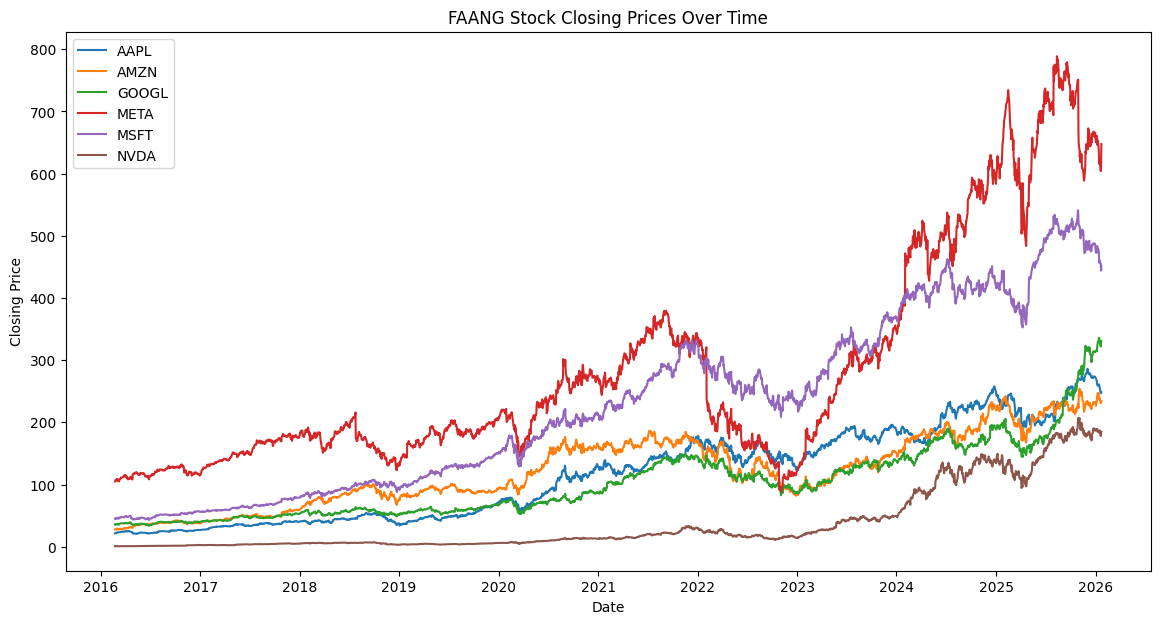

In [31]:
plt.figure(figsize=(14,7))

# Loop through each company ticker
for ticker in df["Ticker"].unique():
    
    # Filter data for current company
    company_df = df[df["Ticker"] == ticker]
    
    # Plot closing prices
    plt.plot(
        company_df["Date"],
        company_df["Close"],
        label=ticker
    )

# Chart labels
plt.title("FAANG Stock Closing Prices Over Time")
plt.xlabel("Date")
plt.ylabel("Closing Price")

# Show legend
plt.legend()

# Display chart
plt.show()

In [33]:
# Create a new column containing the PREVIOUS day's closing price
# shift(1) moves the Close column down by 1 row
meta_df["Prev_Close"] = meta_df["Close"].shift(1)

# Calculate the daily return manually
# Formula:
# (Today's Close - Yesterday's Close) / Yesterday's Close
meta_df["Daily_Return"] = (
    (meta_df["Close"] - meta_df["Prev_Close"])
    / meta_df["Prev_Close"]
)

# View the columns to understand the calculation
meta_df[["Date", "Close", "Prev_Close", "Daily_Return"]].head()

,Date,Close,Prev_Close,Daily_Return
3,2016-02-23,104.728432,NaN,NaN
9,2016-02-24,106.138588,104.728432,0.013465
15,2016-02-25,107.320328,106.138588,0.011134
21,2016-02-26,107.171379,107.320328,-0.001388
27,2016-02-29,106.178314,107.171379,-0.009266


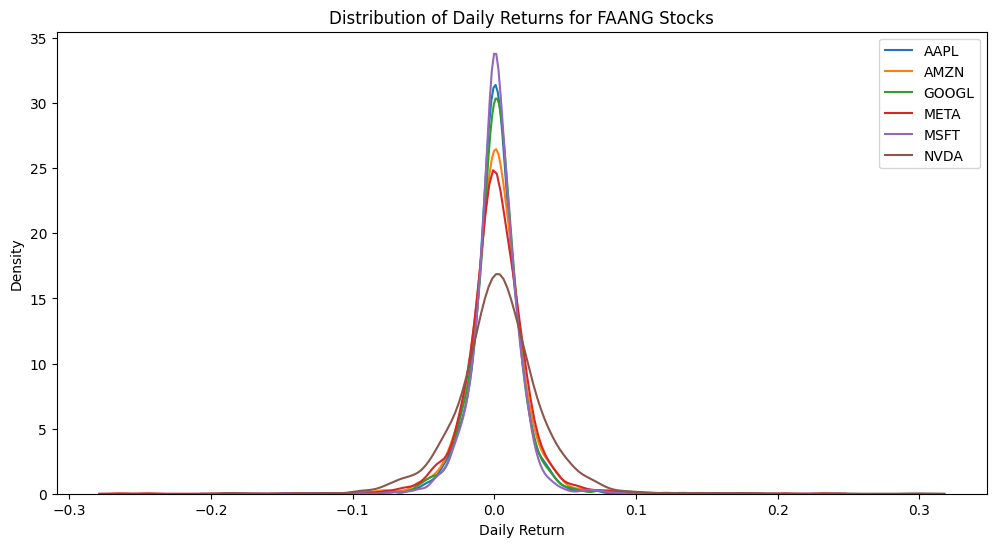

In [35]:
# Create chart size
plt.figure(figsize=(12,6))

# Loop through each unique company ticker
for ticker in df["Ticker"].unique():
    
    # Filter dataframe for ONE company
    company_df = df[df["Ticker"] == ticker].copy()
    
    # Create previous day's closing price
    company_df["Prev_Close"] = company_df["Close"].shift(1)
    
    # Calculate daily return
    company_df["Daily_Return"] = (
        (company_df["Close"] - company_df["Prev_Close"])
        / company_df["Prev_Close"]
    )
    
    # Plot smooth distribution curve
    sns.kdeplot(
        company_df["Daily_Return"].dropna(),
        label=ticker
    )

# Add chart title and labels
plt.title("Distribution of Daily Returns for FAANG Stocks")
plt.xlabel("Daily Return")
plt.ylabel("Density")

# Show company labels
plt.legend()

# Display chart
plt.show()

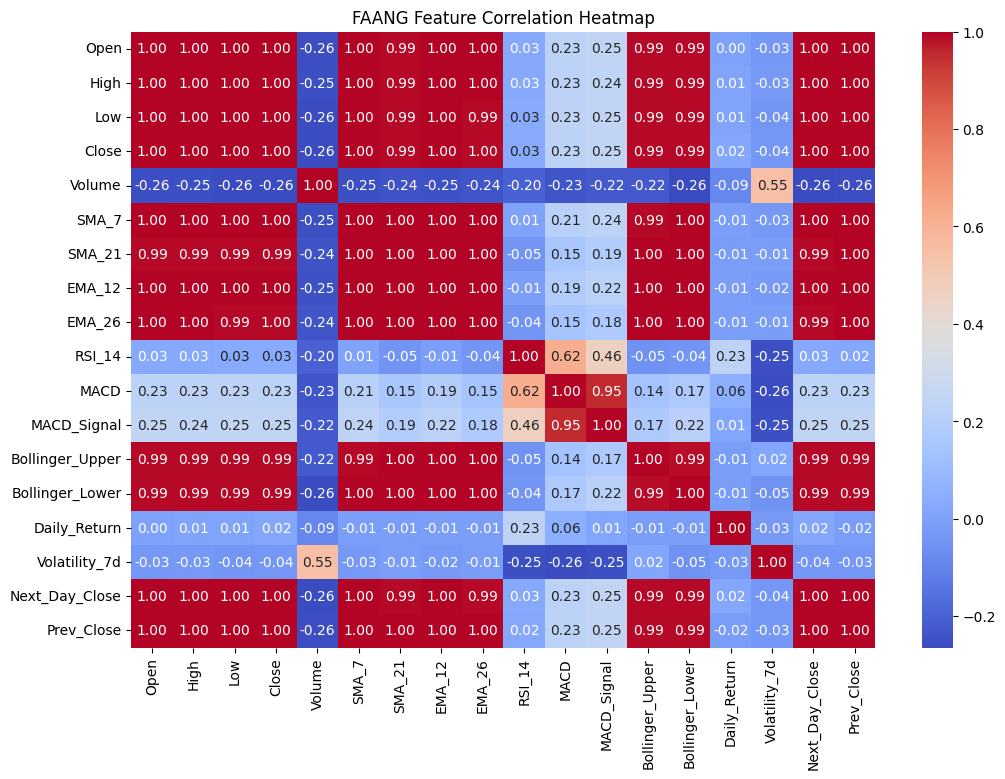

In [38]:
corr_matrix = numeric_df.corr()

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12,8))

sns.heatmap(
    corr_matrix,
    annot=True,      # <-- this adds numbers
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("FAANG Feature Correlation Heatmap")
plt.show()

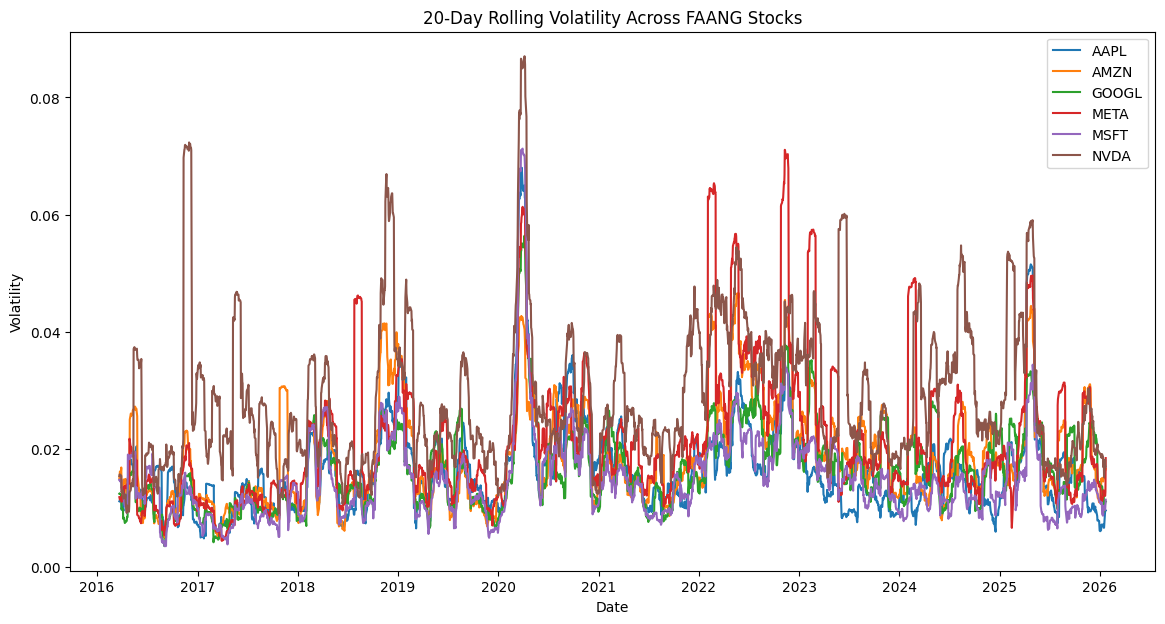

In [41]:
company_df["Volatility_20_norm"] = (
    company_df["Volatility_20"] / company_df["Volatility_20"].iloc[0]) * 100

import matplotlib.pyplot as plt

plt.figure(figsize=(14,7))

for ticker in df["Ticker"].unique():
    
    company_df = df[df["Ticker"] == ticker].copy()
    company_df = company_df.sort_values("Date")
    
    # returns
    company_df["Prev_Close"] = company_df["Close"].shift(1)
    company_df["Daily_Return"] = (
        (company_df["Close"] - company_df["Prev_Close"])
        / company_df["Prev_Close"]
    )
    
    # volatility
    company_df["Volatility_20"] = company_df["Daily_Return"].rolling(20).std()
    
    # REMOVE NaN values BEFORE plotting
    vol = company_df.dropna(subset=["Volatility_20"])
    
    plt.plot(
        vol["Date"],
        vol["Volatility_20"],
        label=ticker
    )

plt.title("20-Day Rolling Volatility Across FAANG Stocks")
plt.xlabel("Date")
plt.ylabel("Volatility")
plt.legend()
plt.show()

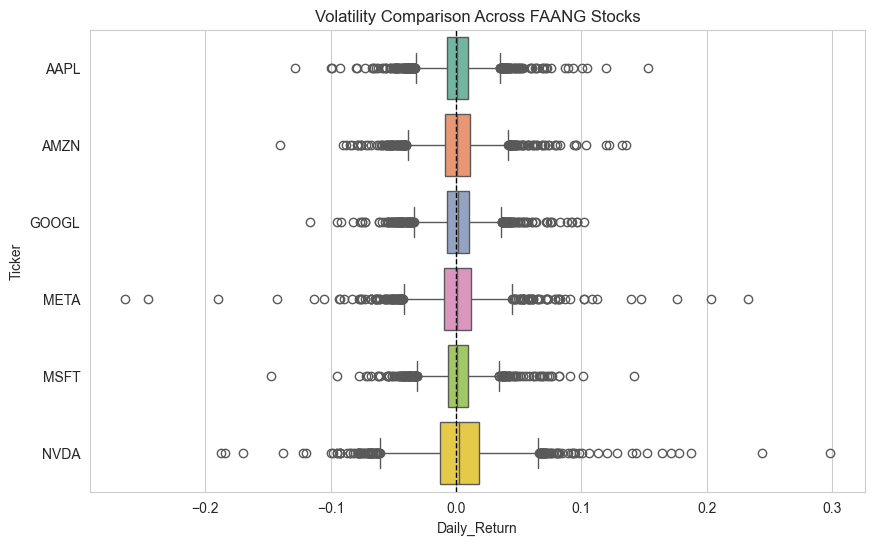

In [45]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_style("whitegrid")

plt.figure(figsize=(10,6))

# compute returns (safe version)
df = df.sort_values("Date")
df["Prev_Close"] = df.groupby("Ticker")["Close"].shift(1)
df["Daily_Return"] = (df["Close"] - df["Prev_Close"]) / df["Prev_Close"]

sns.boxplot(
    data=df,
    y="Ticker",
    x="Daily_Return",
    hue="Ticker",      # fixes warning
    palette="Set2"
)

plt.title("Volatility Comparison Across FAANG Stocks")
plt.axvline(0, color="black", linestyle="--", linewidth=1)

plt.legend([], [], frameon=False)  # hides duplicate legend

plt.show()